# Loading the data

In [1]:
import pandas as pd
df = pd.read_csv("/Users/vishnu/v_files/GT/sem2/DVA/project/final_dataset_full.csv")
print (df.head())

/var/folders/_1/jynj9pwd09b0hmkp12z3czw40000gn/T/ipykernel_1136/513682465.py:2: DtypeWarning: Columns (2,6,7,8,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/vishnu/v_files/GT/sem2/DVA/project/final_dataset_full.csv")


             collection_date region_code rank     video_id  \
0  2022-07-01 00:00:00+00:00          AZ   44  DY6bzDVN7Og   
1  2022-07-01 00:00:00+00:00          BR   94  Q5e94mUB7Mc   
2  2022-07-01 00:00:00+00:00          BY    5  aJQOFXYLT0c   
3  2022-07-01 00:00:00+00:00          CH    2  qhrdHl1LZH4   
4  2022-07-01 00:00:00+00:00          CO  138  2GjuXiwbigs   

                                               title  \
0  Brawl Stars: Brawl Talk - New Brawler, Remodel...   
1  Clash Royale: Raise Your Battle Banners! (Upda...   
2  Юрий Шатунов - Каждому свое  / Премьера песни ...   
3                    Noizy x Loredana - Heart attack   
4     JUGAMOS A LAS ESCONDIDAS EN UN SUPERMERCADO !!   

                published_at category_id view_count comment_count  \
0  2022-06-25 20:00:12+00:00        20.0    9814969         29746   
1  2022-06-27 13:43:01+00:00        20.0    3151495          1684   
2  2022-06-29 21:18:00+00:00        10.0    1693027          8753   
3  2022-06-17 

In [2]:
print (df.columns)

Index(['collection_date', 'region_code', 'rank', 'video_id', 'title',
       'published_at', 'category_id', 'view_count', 'comment_count',
       'default_language', 'tag', 'snapshot_type', 'time_to_trend',
       'trending_duration', 'first_seen', 'text_for_nlp'],
      dtype='object')


In [3]:
print(df.shape)
print(df['snapshot_type'].value_counts())
print(df['text_for_nlp'].isna().mean())
print(df['view_count'].eq(0).mean())
print(df[['trending_duration', 'time_to_trend', 'view_count', 'comment_count']].describe())

(10165171, 16)
snapshot_type
entry            3388390
peak             3388390
exit             3388390
snapshot_type          1
Name: count, dtype: int64
0.0
0.0002498728255530576
        trending_duration  time_to_trend  view_count  comment_count
count          10165171.0   1.016517e+07    10165171       10165171
unique              284.0   2.482850e+05     1991315          90160
top                  54.0   1.299806e+01           0              0
freq             221923.0   1.359600e+04        2540         195351


In [2]:
# Fix dtypes and drop the 1 null snapshot row
df = df.dropna(subset=['snapshot_type'])
df['trending_duration'] = pd.to_numeric(df['trending_duration'], errors='coerce')
df['time_to_trend'] = pd.to_numeric(df['time_to_trend'], errors='coerce')

# Remove any rows where collection_date literally equals the column name
df = df[df['collection_date'] != 'collection_date'].reset_index(drop=True)
print(f"Rows after removing duplicate headers: {df.shape[0]}")
df['collection_date'] = pd.to_datetime(df['collection_date'], format='mixed', utc=True)
df['first_seen'] = pd.to_datetime(df['first_seen'], format='mixed', utc=True)
df['published_at'] = pd.to_datetime(df['published_at'], format='mixed', utc=True)


# Confirm fix
print(df.dtypes)
print(df[['trending_duration', 'time_to_trend']].describe())

# Check trending_duration distribution
print(df[df['snapshot_type']=='entry']['trending_duration'].value_counts().head(10))

Rows after removing duplicate headers: 10165170
collection_date      datetime64[ns, UTC]
region_code                       object
rank                              object
video_id                          object
title                             object
published_at         datetime64[ns, UTC]
category_id                       object
view_count                        object
comment_count                     object
default_language                  object
tag                               object
snapshot_type                     object
time_to_trend                    float64
trending_duration                float64
first_seen           datetime64[ns, UTC]
text_for_nlp                      object
dtype: object
       trending_duration  time_to_trend
count       1.016517e+07   1.016517e+07
mean        2.655494e+02   4.146135e+01
std         2.082856e+02   8.506057e+01
min         0.000000e+00  -1.100167e+01
25%         1.080000e+02   7.094722e+00
50%         2.100000e+02   1.424722e+01
75

In [3]:
# Fix remaining dtypes
for col in ['rank', 'view_count', 'comment_count', 'category_id']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check how many negative time_to_trend values exist
print(f"Negative time_to_trend: {(df['time_to_trend'] < 0).sum()}")
print(f"Zero trending_duration: {(df['trending_duration'] == 0).sum()}")

# Clip negatives to 0
df['time_to_trend'] = df['time_to_trend'].clip(lower=0)

# Final dtype check
print(df[['rank', 'view_count', 'comment_count', 'category_id']].describe())

Negative time_to_trend: 434136
Zero trending_duration: 125730
               rank    view_count  comment_count   category_id
count  1.016517e+07  1.016517e+07   1.016517e+07  1.016517e+07
mean   7.076637e+01  5.020612e+06   5.689516e+03  1.983657e+01
std    6.661259e+01  1.671425e+07   4.558680e+04  6.194175e+00
min    1.000000e+00  0.000000e+00   0.000000e+00  1.000000e+00
25%    1.500000e+01  2.128370e+05   2.770000e+02  1.700000e+01
50%    4.200000e+01  6.302000e+05   9.310000e+02  2.200000e+01
75%    1.270000e+02  2.448464e+06   2.801000e+03  2.400000e+01
max    2.000000e+02  1.406988e+09   3.628721e+06  2.900000e+01


# Phase 1 - Feature Engineering:
Censoring flag

Engagement depth ratio (comment count/view count)

One-row-per-video deduplication for BERTopic corpus

Year/month extraction for topic variety index

In [4]:
# ── Phase 1: Feature Engineering ──────────────────────────────

# Filter to entry snapshots only — one row per (video_id, region_code)
entry = df[df['snapshot_type'] == 'entry'].copy()
print(f"Entry snapshots: {entry.shape[0]}")  # expect ~3.38M

# Censoring flag — videos with no exit snapshot were still trending
# when data collection ended
videos_with_exit = df[df['snapshot_type'] == 'exit'][['video_id', 'region_code']].drop_duplicates()
videos_with_exit['has_exit'] = 1

entry = entry.merge(videos_with_exit, on=['video_id', 'region_code'], how='left')
entry['censored'] = entry['has_exit'].isna().astype(int)
entry.drop(columns='has_exit', inplace=True)

print(f"Censored (no exit): {entry['censored'].sum()} ({entry['censored'].mean():.1%})")

# Engagement depth ratio
entry['engagement_depth'] = (
    entry['comment_count'] / entry['view_count'].replace(0, float('nan'))
)

# Temporal features
entry['year'] = entry['first_seen'].dt.year
entry['month'] = entry['first_seen'].dt.to_period('M')

# Deduplicate to one row per video for BERTopic corpus
# Keep entry from the region where video first appeared globally
entry_sorted = entry.sort_values('first_seen')
df_unique = entry_sorted.drop_duplicates(subset='video_id', keep='first').reset_index(drop=True)

print(f"Unique videos for BERTopic: {df_unique.shape[0]}")
print(f"Null text_for_nlp: {df_unique['text_for_nlp'].isna().sum()}")

# Fill any null text_for_nlp with title as fallback
df_unique['text_for_nlp'] = df_unique['text_for_nlp'].fillna(df_unique['title'])

# Final sanity check
print(df_unique[['trending_duration', 'time_to_trend', 'engagement_depth', 'censored']].describe())

Entry snapshots: 3388390
Censored (no exit): 0 (0.0%)


/var/folders/_1/jynj9pwd09b0hmkp12z3czw40000gn/T/ipykernel_1136/281134441.py:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  entry['month'] = entry['first_seen'].dt.to_period('M')


Unique videos for BERTopic: 725789
Null text_for_nlp: 0
       trending_duration  time_to_trend  engagement_depth  censored
count      725789.000000  725789.000000     725583.000000  725789.0
mean          194.604889      26.161005          0.003398       0.0
std           174.521920      60.227664          0.007189       0.0
min             0.000000       0.000000          0.000000       0.0
25%            66.000000       4.997222          0.000611       0.0
50%           150.000000      11.364167          0.001914       0.0
75%           258.000000      19.500000          0.004172       0.0
max           888.000000     878.998889          1.867333       0.0


Censored = 0 — every video has a confirmed exit snapshot. The dataset was pre-constructed this way. Drop the censoring column, and note this in your survival analysis write-up: all trending durations are fully observed, no censoring needed. This actually simplifies the survival analysis — Kaplan-Meier still applies, just without the censoring complexity.

Engagement depth mean = 0.003 — 0.3% comment rate per view is expected for YouTube at scale. Distribution looks clean.

# Phase 2 - BERTopic

In [9]:
!pip install bertopic sentence-transformers umap-learn hdbscan

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 54.8 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 136.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 34.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 96.7 MB/s  0:00:00
Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
  Created wheel for hdbscan: filename=hdbscan-0.8.42-cp310-cp310-macosx_11_0_arm64.whl size=665969 sha256=8812b803539f2dfc6558776e107ff030451e4cd8bc0292cf41f9ab7fd405f07b
  Stored in directory: /Users/vishnu/Library/Caches/pip/wheels/ea/d7/8d/51d81c8a7f17da5c85c198d3dd9d1afe14f6288bbe9c827a37
Successfully built hdbscan
  Attempting uninstall: regex
    Found existing installation: regex 2024.11.6
    U

### Embeddings for each video (need to run only once)

It converted each video's text into a 384-dimensional numerical vector that captures semantic meaning.

384 is the hidden size of this specific model

The output (725789, 384): One 384-dimensional vector per unique video. UMAP should compresses this from 384 dimensions down to 5 for clustering.

In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer
import torch

docs = df_unique['text_for_nlp'].tolist()
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
embedding_model = SentenceTransformer(
    'paraphrase-multilingual-MiniLM-L12-v2',
    device=device
)

embeddings = embedding_model.encode(
    docs,                        # df_unique['text_for_nlp'].tolist() — 725,789 docs
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True
)

np.save('/Users/vishnu/v_files/GT/sem2/DVA/project/embeddings.npy', embeddings)

### Topic modelling

BERTopic - for the top 5 Youtube's predefined category IDs to cluster that category's videos into sub-themes.

Entropy - within each category, how evenly distributed are the subthemes each year? Declining entropy = fewer sub-themes dominating

Running it like this within each category reduces language diversity within each corpus and produces semantically coherent subtopics.


In [26]:
import numpy as np
import pandas as pd
import re
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# ── Load embeddings ────────────────────────────────────────────
embeddings = np.load('/Users/vishnu/v_files/GT/sem2/DVA/project/embeddings.npy')

# ── Merge category_label into df_unique ───────────────────────
df_unique_cat = df_unique.merge(
    entry[['video_id', 'category_label']].drop_duplicates(subset='video_id'),
    on='video_id',
    how='left'
)

# ── Config per category ────────────────────────────────────────
# min_cluster_size scaled to corpus size
category_configs = {
    'Entertainment': {'min_cluster_size': 200, 'min_samples': 10},
    'People & Blogs': {'min_cluster_size': 100, 'min_samples': 10},
    'Sports':         {'min_cluster_size': 100, 'min_samples': 10},
    'Gaming':         {'min_cluster_size': 100, 'min_samples': 10},
    'Music':          {'min_cluster_size': 100, 'min_samples': 10},
}

# ── Results storage ───────────────────────────────────────────
all_topic_results = {}

for category, config in category_configs.items():

    print(f"\n{'='*60}")
    print(f"Running BERTopic for: {category}")
    print(f"{'='*60}")

    # Filter to category
    cat_mask = df_unique_cat['category_label'] == category
    df_cat = df_unique_cat[cat_mask].reset_index(drop=True)
    original_indices = df_unique_cat[cat_mask].index.to_numpy()
    embeddings_cat = embeddings[original_indices]
    docs_cat = df_cat['text_for_nlp_clean'].tolist()

    print(f"Documents: {len(docs_cat)}")

    # BERTopic components
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=config['min_cluster_size'],
        min_samples=config['min_samples'],
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True,
        core_dist_n_jobs=1
    )

    vectorizer = CountVectorizer(
        stop_words='english',
        min_df=10,
        ngram_range=(1, 2),
        token_pattern=r"(?u)\b(?!unknown\b)[a-zA-Z][a-zA-Z]+\b"
    )

    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        nr_topics='auto',
        verbose=False      # suppress per-step logs for cleaner output
    )

    topics, probs = topic_model.fit_transform(docs_cat, embeddings=embeddings_cat)

    df_cat['topic_id'] = topics
    df_cat['topic_prob'] = probs

    # Sanity check
    topic_info = topic_model.get_topic_info()
    noise_pct = (df_cat['topic_id'] == -1).mean()
    n_topics = topic_info[topic_info['Topic'] != -1].shape[0]

    print(f"Noise: {noise_pct:.1%}")
    print(f"Topics found: {n_topics}")
    print(topic_info[['Topic', 'Count', 'Name']].head(15).to_string())

    # Top topic keywords
    print(f"\nTop topics in {category}:")
    for i in range(min(10, n_topics)):
        words = [w for w, _ in topic_model.get_topic(i)[:5]]
        print(f"  Topic {i}: {words}")

    # Topic variety by year
    df_cat['year'] = pd.to_datetime(df_cat['first_seen']).dt.year
    topic_variety = (
        df_cat[df_cat['topic_id'] != -1]
        .groupby('year')['topic_id']
        .nunique()
        .reset_index()
        .rename(columns={'topic_id': 'distinct_topics'})
    )
    print(f"\nTopic variety by year:\n{topic_variety}")

    # Shannon entropy by year
    def shannon_entropy(series):
        counts = series.value_counts(normalize=True)
        return -(counts * np.log2(counts)).sum()

    entropy_by_year = (
        df_cat[df_cat['topic_id'] != -1]
        .groupby('year')['topic_id']
        .apply(shannon_entropy)
        .reset_index()
        .rename(columns={'topic_id': 'entropy'})
    )
    print(f"\nShannon entropy by year:\n{entropy_by_year}")

    # Store results
    all_topic_results[category] = {
        'df': df_cat,
        'model': topic_model,
        'topic_info': topic_info,
        'entropy': entropy_by_year,
        'topic_variety': topic_variety
    }

    # Save per-category outputs
    cat_slug = category.lower().replace(' ', '_').replace('&', 'and')
    topic_model.save(
        f'/Users/vishnu/v_files/GT/sem2/DVA/project/bertopic_{cat_slug}'
    )
    df_cat.to_csv(
        f'/Users/vishnu/v_files/GT/sem2/DVA/project/topics_{cat_slug}.csv',
        index=False
    )
    entropy_by_year.to_csv(
        f'/Users/vishnu/v_files/GT/sem2/DVA/project/entropy_{cat_slug}.csv',
        index=False
    )

print("\n\nAll categories done.")
print("Files saved for: Entertainment, People & Blogs, Sports, Gaming, Music")


Running BERTopic for: Entertainment
Documents: 205059
Noise: 51.3%
Topics found: 30
    Topic   Count                               Name
0      -1  105125              -1_shorts_video_la_tv
1       0   84952             0_tv_episode_new_movie
2       1    5449    1_food_challenge_mcdonalds_fast
3       2     850        2_makeup_fail_hacks_tik tok
4       3     719              3_dog_mio_cute_il mio
5       4     471       4_sidemen_prank_moments_fake
6       5     450            5_police_plus_crime_usa
7       6     440                 6_au_en_les_france
8       7     390          7_iphone_pro_max_unboxing
9       8     390           8_yeni_youtube_final_ali
10      9     388            9_vida_la vida_en el_en
11     10     361               10_auto_car_sam_cars
12     11     320                11_ao_da_em_luisito
13     12     319                   12_day_got_se_ci
14     13     314  13_comedy_talent_entertainment_tv

Top topics in Entertainment:
  Topic 0: ['tv', 'episode', 'new', '

2026-03-31 11:23:32,101 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.



Topic variety by year:
   year  distinct_topics
0  2022               30
1  2023               30
2  2024               29
3  2025               28

Shannon entropy by year:
   year   entropy
0  2022  1.097058
1  2023  1.247259
2  2024  1.146199
3  2025  1.259018

Running BERTopic for: People & Blogs
Documents: 98661
Noise: 49.1%
Topics found: 13
    Topic  Count                        Name
0      -1  48477     -1_vlog_vs_shorts_video
1       0  47716     0_vlog_shorts_video_new
2       1    504  1_life_tiktok_shorts_video
3       2    304      2_tiktok_new_tv_shorts
4       3    254             3_na_mi_se_vlog
5       4    208           4_mi_life_vs_time
6       5    196                 5_vs_tv_di_
7       6    191       6_tiktok_shorts_di_tv
8       7    177             7_na_time_se_di
9       8    168               8_se_na_vs_di
10      9    134     9_life_tiktok_di_shorts
11     10    123            10_na_mi_time_vs
12     11    105         11_vs_video_life_se
13     12    104    

2026-03-31 11:24:35,457 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.



Topic variety by year:
   year  distinct_topics
0  2022               13
1  2023               13
2  2024               13
3  2025               13

Shannon entropy by year:
   year   entropy
0  2022  0.447097
1  2023  0.469395
2  2024  0.425250
3  2025  0.433148

Running BERTopic for: Sports
Documents: 86203
Noise: 32.5%
Topics found: 42
    Topic  Count                                        Name
0      -1  27981              -1_league_football_madrid_real
1       0  45142                0_vs_highlights_cricket_live
2       1   1158               1_nba_lebron_basketball_james
3       2   1134           2_classic_training_challenge_alex
4       3   1020                3_racing_grand_bull_red bull
5       4    622                4_cycling_tour_france_racing
6       5    615                     5_shorts_viral_espn_ufc
7       6    539              6_golf_championship_tour_round
8       7    452                7_noticias_pedro_treino_hoje
9       8    446             8_night_entertainme

...


Topic variety by year:
   year  distinct_topics
0  2022               40
1  2023               42
2  2024               42
3  2025               42

Shannon entropy by year:
   year   entropy
0  2022  1.685694
1  2023  2.003285
2  2024  1.812258
3  2025  1.911620

Running BERTopic for: Gaming
Documents: 79789
Noise: 35.7%
Topics found: 81
    Topic  Count                                                        Name
0      -1  28520                    -1_minecraft_minecraft minecraft_rp_game
1       0  27183                                        0_fifa_fc_roblox_wot
2       1   2490  1_fortnite_fortnite fortnite_battle royale_fortnite battle
3       2   1543                             2_free_ff_free free_garena free
4       3   1462                           3_gta_gta gta_franklin_gta online
5       4    929                               4_pokemon_nintendo_gen_shield
6       5    811                       5_skibidi_toilet_skibidi toilet_titan
7       6    745                          

2026-03-31 11:26:08,678 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.



Topic variety by year:
   year  distinct_topics
0  2022               81
1  2023               81
2  2024               81
3  2025               78

Shannon entropy by year:
   year   entropy
0  2022  3.491050
1  2023  3.783593
2  2024  3.485670
3  2025  3.430732

Running BERTopic for: Music
Documents: 70952
Noise: 49.3%
Topics found: 66
    Topic  Count                                            Name
0      -1  34982                     -1_rap_video_official_music
1       0   6679           0_video_music_official_official video
2       1   5093              1_prod_clip officiel_officiel_clip
3       2   3277                            2_ao vivo_vivo_ao_la
4       3   3112  3_official_official video_video_official music
5       4   2976                         4_songs_song_latest_new
6       5   1656                       5_mv_nct_official mv_kpop
7       6    706                       6_cheb_yeni_rai_yeni klip
8       7    696                          7_remix_tiago_pzk_bebe
9       8

2026-03-31 11:26:51,481 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.



Topic variety by year:
   year  distinct_topics
0  2022               66
1  2023               66
2  2024               66
3  2025               65

Shannon entropy by year:
   year   entropy
0  2022  4.465467
1  2023  4.564023
2  2024  4.554718
3  2025  4.496424


All categories done.
Files saved for: Entertainment, People & Blogs, Sports, Gaming, Music


visualizing each sub-category after running bertopic

didn't visualize "Entertainment" (the top 1 category) - becasue BERTopic produced 338 subtopics with 52% noise

sports: 42 topics loaded
gaming: 81 topics loaded
music: 66 topics loaded


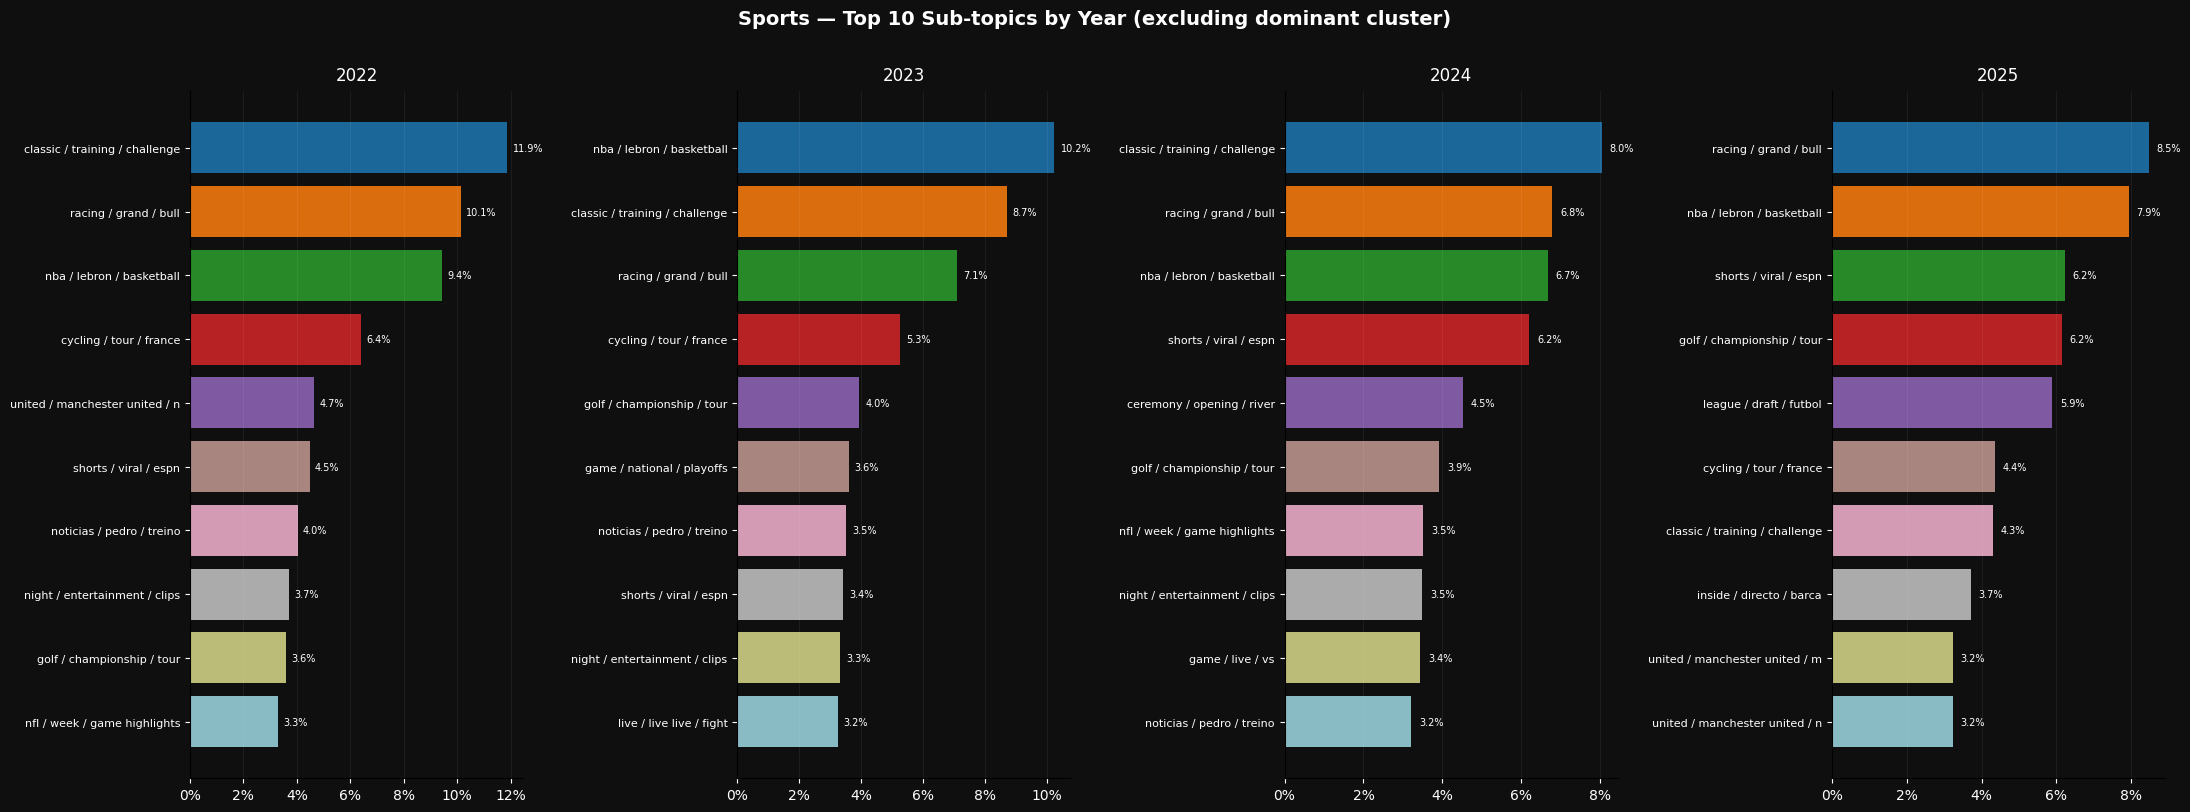

Saved viz_subtopics_sports.png


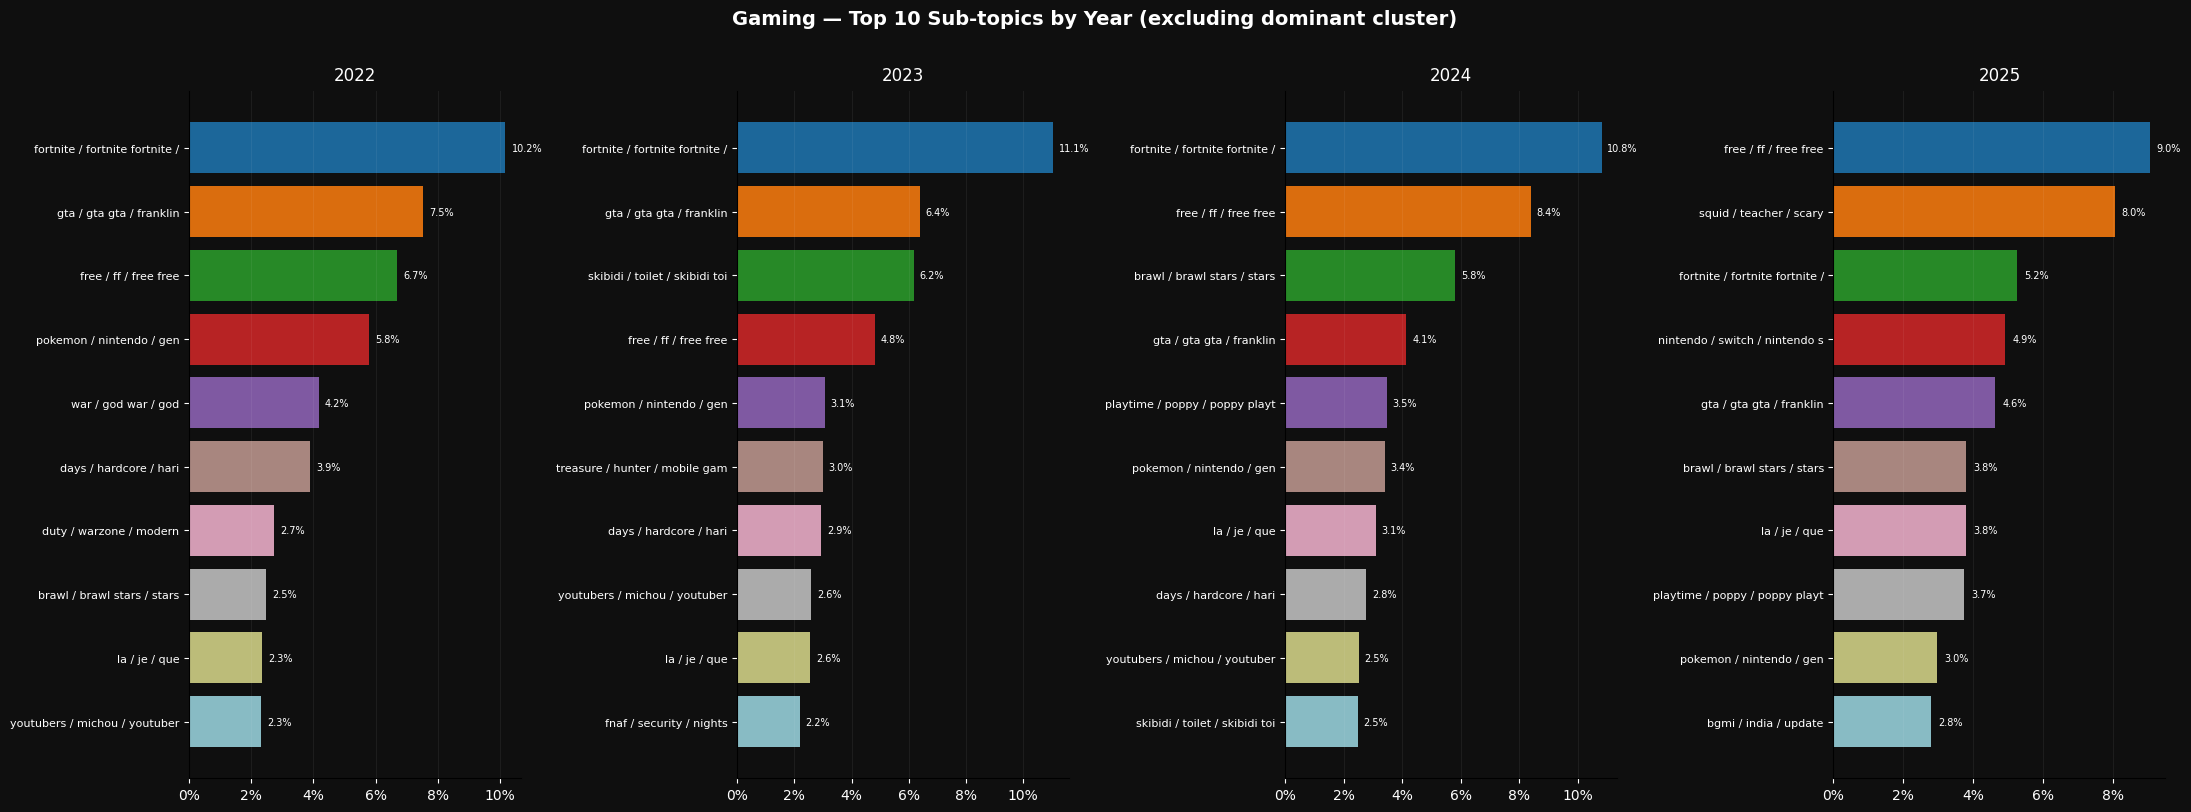

Saved viz_subtopics_gaming.png


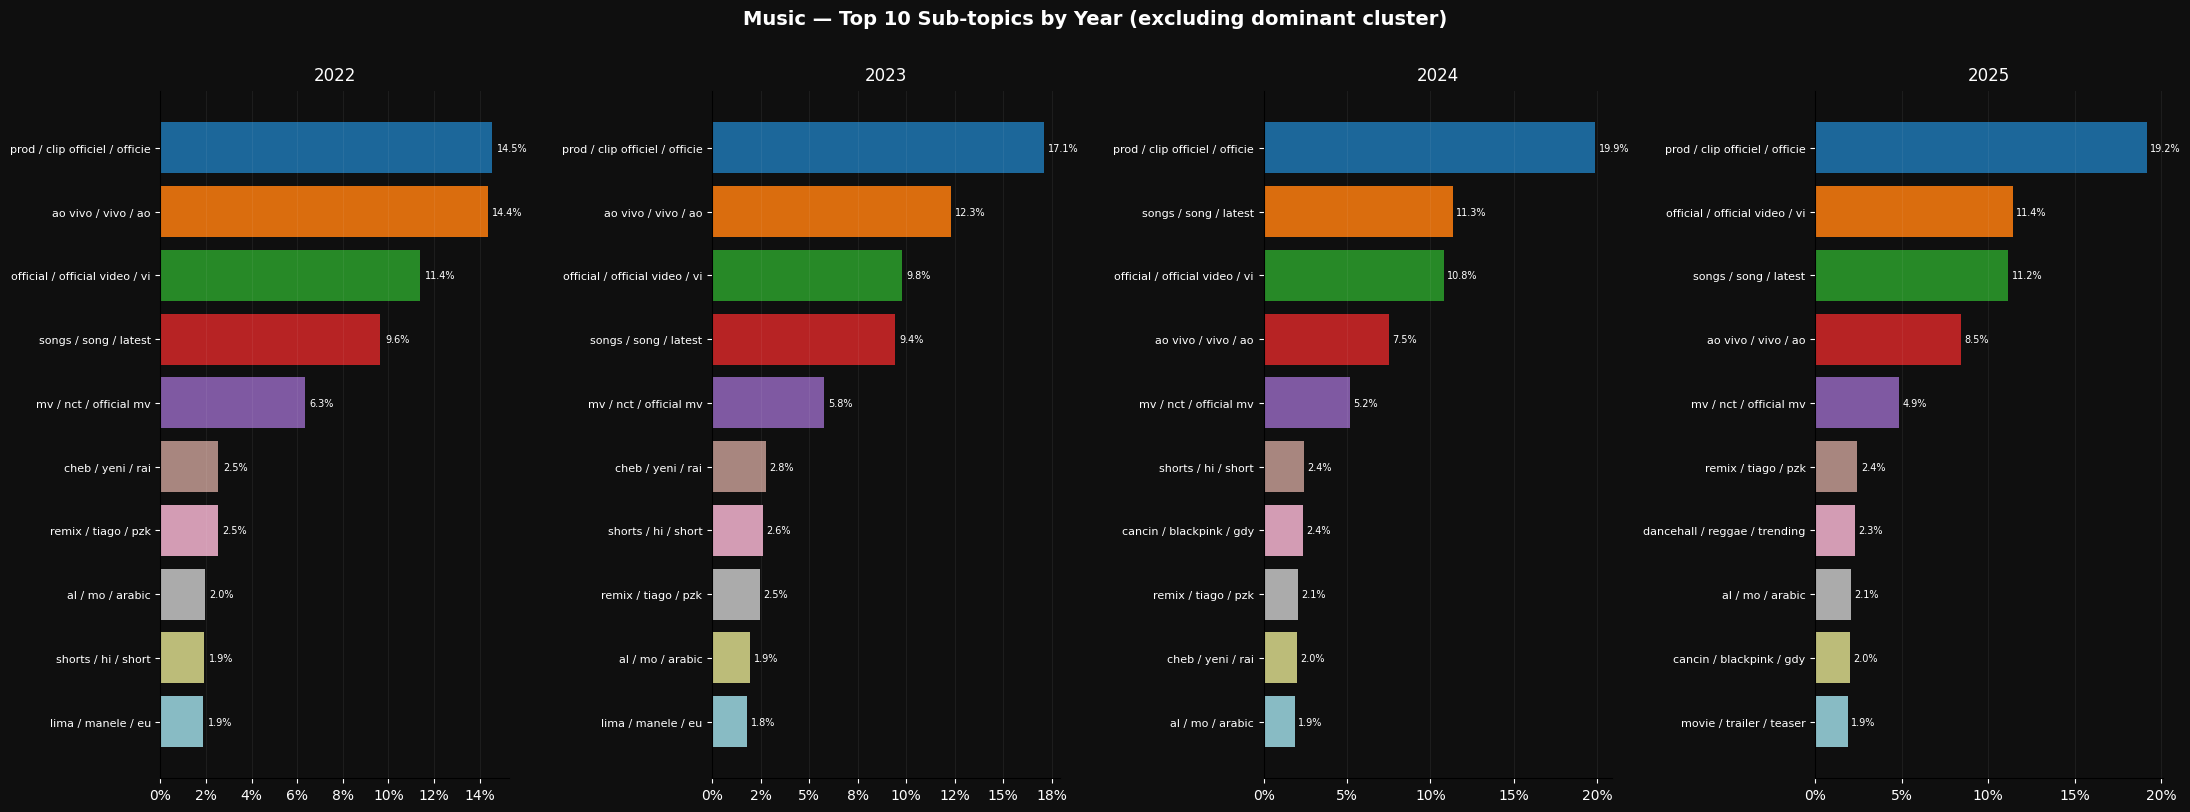

Saved viz_subtopics_music.png


In [32]:
from bertopic import BERTopic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#0f0f0f',
    'axes.labelcolor': 'white', 'xtick.color': 'white',
    'ytick.color': 'white', 'text.color': 'white',
    'axes.titlecolor': 'white', 'legend.facecolor': '#1a1a1a',
    'axes.spines.top': False, 'axes.spines.right': False,
})

SAVEPATH = '/Users/vishnu/v_files/GT/sem2/DVA/project/'

# ── Load label maps from saved models ─────────────────────────
topic_label_maps = {}
for cat_slug in ['sports', 'gaming', 'music']:
    model = BERTopic.load(f'{SAVEPATH}bertopic_{cat_slug}')
    label_map = {}
    for tid in model.get_topic_info()['Topic']:
        if tid == -1:
            continue
        words = [w for w, _ in model.get_topic(tid)[:3]]
        label_map[tid] = ' / '.join(words)
    topic_label_maps[cat_slug] = label_map
    print(f"{cat_slug}: {len(label_map)} topics loaded")


# ═══════════════════════════════════════════════════════════════
# VIZ 1 — Top sub-topics by year (excluding mega-topic 0)
# ═══════════════════════════════════════════════════════════════

def plot_top_topics_by_year(cat_slug, cat_title, top_n=10):
    df = pd.read_csv(f'{SAVEPATH}topics_{cat_slug}.csv')
    # Use topic_id column — ignore topic_label column entirely
    df = df[df['topic_id'] != -1].copy()
    df = df[df['topic_id'] != 0].copy()   # exclude mega-topic
    df['year'] = pd.to_datetime(df['first_seen']).dt.year
    label_map = topic_label_maps[cat_slug]

    years = sorted(df['year'].unique())
    fig, axes = plt.subplots(1, len(years), figsize=(22, 8))
    fig.patch.set_facecolor('#0f0f0f')
    fig.suptitle(
        f'{cat_title} — Top {top_n} Sub-topics by Year (excluding dominant cluster)',
        fontsize=14, fontweight='bold', y=1.01
    )
    colors = cm.tab20(np.linspace(0, 1, top_n))

    for i, year in enumerate(years):
        ax = axes[i]
        ax.set_facecolor('#0f0f0f')
        year_df = df[df['year'] == year]
        top = year_df['topic_id'].value_counts().head(top_n).reset_index()
        top.columns = ['topic_id', 'count']
        top['pct'] = top['count'] / year_df.shape[0]

        # Get labels directly from model
        labels = [label_map.get(int(tid), f'T{tid}')[:30]
                  for tid in top['topic_id']]

        bars = ax.barh(
            range(len(top)), top['pct'].values,
            color=colors[:len(top)], alpha=0.85
        )
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(str(year), fontsize=12, pad=8)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
        ax.invert_yaxis()
        ax.grid(axis='x', color='white', alpha=0.06)

        for bar, val in zip(bars, top['pct'].values):
            ax.text(
                bar.get_width() + 0.002,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1%}', va='center', fontsize=7, color='white'
            )

    plt.tight_layout()
    plt.savefig(
        f'{SAVEPATH}viz_subtopics_{cat_slug}.png',
        dpi=150, bbox_inches='tight', facecolor='#0f0f0f'
    )
    plt.show()
    print(f"Saved viz_subtopics_{cat_slug}.png")


plot_top_topics_by_year('sports', 'Sports')
plot_top_topics_by_year('gaming', 'Gaming')
plot_top_topics_by_year('music',  'Music')




Shannon entropy measures how evenly distributed / diverse attention is across topics.

In [42]:
# Use category_id directly — no mapping needed
e = entry[entry['category_id'].notna()].copy()
e['category_id'] = e['category_id'].astype(int)

# Shannon entropy by year
entropy_by_year = (
    e.groupby('year')['category_id']
    .apply(shannon_entropy)
    .reset_index()
    .rename(columns={'category_id': 'entropy'})
)
print("Shannon entropy by year:")
print(entropy_by_year)
entropy_by_year.to_csv(f'{SAVEPATH}entropy_by_year.csv', index=False)

# Category share by year
cat_share = (
    e.groupby(['year', 'category_id'])
    .size()
    .reset_index(name='count')
)
cat_share['total'] = cat_share.groupby('year')['count'].transform('sum')
cat_share['share'] = cat_share['count'] / cat_share['total']
cat_share.to_csv(f'{SAVEPATH}category_share_by_year.csv', index=False)

# Top-3 dominance
top3_dominance = (
    cat_share.groupby('year')
    .apply(lambda x: x.nlargest(3, 'share')['share'].sum())
    .reset_index()
    .rename(columns={0: 'top3_share'})
)
print("\nTop-3 topics dominance by year:")
print(top3_dominance)
top3_dominance.to_csv(f'{SAVEPATH}top3_dominance_by_year.csv', index=False)

# Cross-country cosine similarity
country_cat = pd.read_csv(f'{SAVEPATH}country_category_distribution.csv')

pivot_sim = country_cat.pivot_table(
    index=['region_code', 'year'],
    columns='category_label',
    values='share',
    fill_value=0
).reset_index()

similarity_records = []
for year in sorted(pivot_sim['year'].unique()):
    year_data = pivot_sim[pivot_sim['year'] == year].drop(
        columns=['region_code', 'year']
    )
    sim_matrix = cosine_similarity(year_data)
    n = sim_matrix.shape[0]
    upper = sim_matrix[np.triu_indices(n, k=1)]
    similarity_records.append({
        'year': year,
        'mean_cosine_similarity': upper.mean(),
        'std_cosine_similarity': upper.std()
    })

similarity_df = pd.DataFrame(similarity_records)
print("\nCross-country cosine similarity by year:")
print(similarity_df)
similarity_df.to_csv(
    f'{SAVEPATH}crosscountry_similarity_by_year.csv', index=False
)

Shannon entropy by year:
   year       entropy
0  2022 -7.862123e+07
1  2023 -1.097323e+08
2  2024 -7.711924e+07
3  2025 -3.065604e+07

Top-3 topics dominance by year:
   year  top3_share
0  2022    0.532474
1  2023    0.540126
2  2024    0.565611
3  2025    0.565899

Cross-country cosine similarity by year:
   year  mean_cosine_similarity  std_cosine_similarity
0  2022                0.854274               0.101686
1  2023                0.855805               0.106254
2  2024                0.866867               0.087114
3  2025                0.853398               0.096538


Top-3 Categories Capture Growing Share of Trending Videos !!

This is evidence of content concentration (53.2% - 56.5%, +3.3% in 3 years)